## 1. Importación de librerías

En esta primera etapa se importan las librerías necesarias para realizar el proceso de limpieza y preparación del conjunto de datos.

Las herramientas utilizadas permitirán manipular la información, gestionar valores faltantes, transformar variables y registrar las modificaciones realizadas durante el proceso de preparación.

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Manejo de fechas
from datetime import datetime

# Configuración de visualización
pd.set_option('display.max_columns', None)

## 2. Carga del conjunto de datos

En esta etapa se carga el dataset original almacenado en formato JSON.

Es importante destacar que el archivo original no será modificado durante el proceso de limpieza. Todas las transformaciones se realizarán sobre una copia de trabajo, preservando el conjunto de datos original como referencia.

In [2]:
from pathlib import Path

# Ruta base del proyecto
BASE_DIR = Path.cwd().parent

# Ruta al dataset original
RUTA_DATASET = BASE_DIR / "data" / "raw" / "streaming_users_dirty.json"

# Cargar dataset
df = pd.read_json(RUTA_DATASET)

print("✅ Dataset cargado correctamente.")

✅ Dataset cargado correctamente.


## 3. Creación de una copia de trabajo

Antes de comenzar el proceso de limpieza se genera una copia independiente del conjunto de datos.

Trabajar sobre una copia permite preservar el dataset original sin modificaciones y garantiza la reproducibilidad del proyecto. De esta manera, cualquier transformación realizada podrá revertirse fácilmente recurriendo al archivo original.

In [3]:
# Crear una copia del dataset
df_limpio = df.copy()

print("✅ Copia de trabajo creada correctamente.")

✅ Copia de trabajo creada correctamente.


## 4. Registro del estado inicial del dataset

Antes de aplicar cualquier transformación, se registran las principales características del conjunto de datos.

Este registro servirá como punto de comparación para evaluar el impacto de cada etapa de limpieza y facilitará la construcción del log del proceso ETL.

In [4]:
print("Estado inicial del dataset")
print("-" * 40)
print(f"Cantidad de filas: {df_limpio.shape[0]}")
print(f"Cantidad de columnas: {df_limpio.shape[1]}")
print(f"Valores faltantes: {df_limpio.isnull().sum().sum()}")
print(f"Registros duplicados: {df_limpio.duplicated().sum()}")

Estado inicial del dataset
----------------------------------------
Cantidad de filas: 8160
Cantidad de columnas: 8
Valores faltantes: 753
Registros duplicados: 126


## 5. Verificación de registros duplicados

Durante la inspección inicial se detectó la existencia de registros duplicados.

Antes de proceder a su eliminación, resulta conveniente visualizar algunos ejemplos con el objetivo de verificar que se trata de filas completamente repetidas y justificar posteriormente la decisión de eliminarlas.

In [5]:
# Mostrar algunos registros duplicados

duplicados = df_limpio[df_limpio.duplicated(keep=False)]

duplicados.head(20)

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
37,10037,33,Básico,611.0,Colombia,Documental,2019-09-29,2
52,10052,25,Básico,465.7,Colombia,Acción,2022-03-31,1
117,10117,29,Estándar,713.9,Brasil,Documental,2020-12-20,1
128,10128,19,Básico,638.7,Argentina,Drama,2020-06-17,1
156,10156,43,Básico,592.8,Brasil,Romance,2021-10-25,0
308,10308,33,Básico,310.9,Uruguay,Comedia,2025-10-24,1
333,10333,19,Estándar,1230.1,Uruguay,Romance,2024-09-03,0
373,10373,33,Básico,183.1,México,Documental,2020-05-23,1
375,10375,32,Premium,1223.3,Uruguay,Comedia,2020-12-22,2
409,10409,34,Básico,742.4,Perú,Comedia,2025-02-10,2


## 6. Eliminación de registros duplicados

Durante la inspección inicial se identificó la presencia de **126 registros duplicados**.

Los registros duplicados pueden generar sesgos en los análisis posteriores, ya que un mismo caso sería contabilizado más de una vez. Por este motivo, se eliminarán conservando únicamente la primera aparición de cada registro.

Esta decisión se encuentra respaldada por la evidencia obtenida en el Notebook 01 y en la verificación realizada en la sección anterior.

In [6]:
# Cantidad de filas antes de eliminar duplicados
filas_antes = df_limpio.shape[0]

# Eliminar registros duplicados
df_limpio = df_limpio.drop_duplicates()

# Cantidad de filas después
filas_despues = df_limpio.shape[0]

# Registros eliminados
eliminados = filas_antes - filas_despues

print("Eliminación de registros duplicados")
print("-" * 40)
print(f"Filas antes: {filas_antes}")
print(f"Filas después: {filas_despues}")
print(f"Registros eliminados: {eliminados}")

Eliminación de registros duplicados
----------------------------------------
Filas antes: 8160
Filas después: 8034
Registros eliminados: 126


### Interpretación

Se eliminaron **126 registros duplicados**, reduciendo el tamaño del conjunto de datos de **8160** a **8034 registros**.

La eliminación de estos registros mejora la calidad del dataset, ya que evita contabilizar más de una vez observaciones idénticas y reduce el riesgo de introducir sesgos en los análisis posteriores.

A partir de esta etapa, todas las transformaciones se realizarán sobre el conjunto de datos libre de registros duplicados.

## 7. Registro de transformaciones

Con el objetivo de garantizar la trazabilidad del proceso de limpieza, se comenzará a construir un registro de las transformaciones aplicadas al conjunto de datos.

Cada modificación realizada quedará documentada indicando el estado del dataset luego de la transformación.

In [7]:
# Crear el log del pipeline

pipeline_log = pd.DataFrame({
    "Paso": ["Estado inicial", "Eliminación de duplicados"],
    "Filas": [8160, filas_despues],
    "Columnas": [8, df_limpio.shape[1]],
    "Valores faltantes": [753, df_limpio.isnull().sum().sum()]
})

pipeline_log

,Paso,Filas,Columnas,Valores faltantes
0,Estado inicial,8160,8,753
1,Eliminación de duplicados,8034,8,753


## 8. Conversión de la variable `last_login_date`

Durante la inspección inicial se observó que la variable `last_login_date` fue interpretada como un dato de tipo `object`.

Sin embargo, esta variable representa una fecha, por lo que resulta conveniente convertirla al tipo `datetime`. Esta transformación facilitará el análisis temporal y permitirá utilizar funciones específicas de manejo de fechas disponibles en Pandas.

In [8]:
# Verificar el tipo de dato antes de la conversión
print("Tipo antes de la conversión:")
print(df_limpio["last_login_date"].dtype)

# Convertir la columna a tipo fecha
df_limpio["last_login_date"] = pd.to_datetime(
    df_limpio["last_login_date"],
    errors="coerce"
)

print("\nTipo después de la conversión:")
print(df_limpio["last_login_date"].dtype)

Tipo antes de la conversión:
object

Tipo después de la conversión:
datetime64[ns]


### Interpretación

La conversión se realizó correctamente, modificando el tipo de dato de la variable `last_login_date` de `object` a `datetime64`.

Esta transformación mejora la calidad del conjunto de datos y permitirá realizar análisis temporales de manera más eficiente en etapas posteriores del proyecto.

### 8.1 Validación de fechas futuras

Una vez convertida la variable al tipo `datetime`, se verifica si existen fechas posteriores a la fecha actual.

Dado que `last_login_date` representa el último acceso de un usuario a la plataforma, una fecha futura constituye un dato inconsistente. En esos casos, el valor será reemplazado por `NaT` (Not a Time), preservando el registro y permitiendo identificar posteriormente los valores faltantes sin introducir información artificial.

In [9]:
fecha_actual = pd.Timestamp.today().normalize()

fechas_futuras = (df_limpio["last_login_date"] > fecha_actual).sum()

print(f"Fechas futuras detectadas: {fechas_futuras}")

# Reemplazar fechas futuras por NaT
df_limpio.loc[
    df_limpio["last_login_date"] > fecha_actual,
    "last_login_date"
] = pd.NaT

print("✅ Fechas futuras reemplazadas por NaT.")

Fechas futuras detectadas: 15
✅ Fechas futuras reemplazadas por NaT.


In [10]:
# Registrar la transformación en el pipeline

pipeline_log.loc[len(pipeline_log)] = {
    "Paso": "Conversión de fechas",
    "Filas": df_limpio.shape[0],
    "Columnas": df_limpio.shape[1],
    "Valores faltantes": df_limpio.isnull().sum().sum()
}

pipeline_log

,Paso,Filas,Columnas,Valores faltantes
0,Estado inicial,8160,8,753
1,Eliminación de duplicados,8034,8,753
2,Conversión de fechas,8034,8,1217


## 9. Identificación de valores numéricos inconsistentes

Durante la inspección inicial se detectaron valores fuera de rango en algunas variables numéricas.

Antes de aplicar cualquier corrección, se identificará la cantidad de registros afectados en cada variable. Esta información permitirá justificar posteriormente la estrategia de tratamiento seleccionada.

In [15]:
# Cantidad de edades inválidas
edad_invalida = (
    (df_limpio["age"] < 13) |
    (df_limpio["age"] > 100)
).sum()

# Cantidad de tiempos de visualización inválidos
tiempo_invalido = (
    (df_limpio["monthly_watch_time_mins"] < 0) |
    (df_limpio["monthly_watch_time_mins"] > 30000)
).sum()

# Cantidad de tickets inválidos
tickets_invalidos = (
    (df_limpio["customer_support_tickets"] < 0) |
    (df_limpio["customer_support_tickets"] > 10)
).sum()

print("Valores inconsistentes detectados")
print("-"*40)
print(f"Edades fuera de rango: {edad_invalida}")
print(f"Tiempos de visualización inválidos: {tiempo_invalido}")
print(f"Tickets negativos: {tickets_invalidos}")

Valores inconsistentes detectados
----------------------------------------
Edades fuera de rango: 120
Tiempos de visualización inválidos: 80
Tickets negativos: 96


## 10. Tratamiento de valores numéricos inconsistentes

Durante la inspección inicial y la verificación realizada en este notebook se identificaron valores numéricos imposibles o fuera del rango esperado en las variables `age`, `monthly_watch_time_mins` y `customer_support_tickets`.

Dado que la cantidad de registros afectados representa una proporción reducida del conjunto de datos, se decidió reemplazar estos valores por `NaN` en lugar de eliminar los registros completos. Esta estrategia permite conservar la mayor cantidad de información posible y facilita la posterior imputación de los datos faltantes utilizando criterios estadísticos.

In [16]:
# Reemplazar edades fuera de rango por NaN
df_limpio.loc[
    (df_limpio["age"] < 13) | (df_limpio["age"] > 100),
    "age"
] = np.nan

# Reemplazar tiempos de visualización inválidos por NaN
df_limpio.loc[
    (df_limpio["monthly_watch_time_mins"] < 0) |
    (df_limpio["monthly_watch_time_mins"] > 30000),
    "monthly_watch_time_mins"
] = np.nan

# Reemplazar tickets inconsistentes por NaN
df_limpio.loc[
    (df_limpio["customer_support_tickets"] < 0) |
    (df_limpio["customer_support_tickets"] > 10),
    "customer_support_tickets"
] = np.nan

print("✅ Los valores inconsistentes fueron reemplazados por NaN.")

✅ Los valores inconsistentes fueron reemplazados por NaN.


Durante la inspección inicial se identificaron valores numéricos fuera del rango esperado en las variables age, monthly_watch_time_mins y customer_support_tickets.

En lugar de eliminar los registros completos, se decidió reemplazar únicamente los valores inconsistentes por NaN. Esta estrategia permite conservar la mayor cantidad de información posible y posibilita una imputación posterior mediante criterios estadísticos adecuados para cada variable.

En particular, para la variable customer_support_tickets también se consideraron inconsistentes los valores excesivamente elevados, ya que no resultan coherentes con el comportamiento general observado en el conjunto de datos.

In [15]:
print("Verificación de valores inconsistentes")
print("-" * 40)

print(
    "Edades fuera de rango:",
    ((df_limpio["age"] < 0) | (df_limpio["age"] > 100)).sum()
)

print(
    "Tiempos de visualización inválidos:",
    (
        (df_limpio["monthly_watch_time_mins"] < 0) |
        (df_limpio["monthly_watch_time_mins"] > 30000)
    ).sum()
)

print(
    "Tickets negativos:",
    (df_limpio["customer_support_tickets"] < 0).sum()
)

Verificación de valores inconsistentes
----------------------------------------
Edades fuera de rango: 0
Tiempos de visualización inválidos: 0
Tickets negativos: 0


### Interpretación

La transformación se realizó correctamente. Los valores numéricos considerados inconsistentes fueron reemplazados por valores nulos (`NaN`), eliminando la presencia de registros fuera del rango definido para las variables analizadas.

Esta estrategia permite preservar la información válida de cada registro y prepara el conjunto de datos para la etapa de imputación de valores faltantes, evitando eliminar observaciones completas por la presencia de un único dato incorrecto.

## 12. Funciones auxiliares

Con el objetivo de evitar la repetición de código y mejorar la organización del proyecto, se implementan funciones auxiliares.

Estas funciones permiten automatizar tareas frecuentes, como el registro de las transformaciones realizadas durante el proceso de limpieza del conjunto de datos.

Su utilización favorece la reutilización del código, mejora la legibilidad del notebook y facilita el mantenimiento del proyecto.

In [17]:
# Crear el DataFrame del pipeline
pipeline_log = pd.DataFrame(
    columns=[
        "Paso",
        "Acción",
        "Filas",
        "Columnas",
        "Valores faltantes",
        "Observaciones"
    ]
)

In [18]:
def registrar_pipeline(
    paso,
    accion,
    dataframe,
    observaciones=""
):
    """
    Registra una transformación realizada sobre el dataset.
    """

    global pipeline_log

    pipeline_log.loc[len(pipeline_log)] = {

        "Paso": paso,

        "Acción": accion,

        "Filas": dataframe.shape[0],

        "Columnas": dataframe.shape[1],

        "Valores faltantes": dataframe.isnull().sum().sum(),

        "Observaciones": observaciones

    }

In [19]:
# Función de Resumen

def resumen_dataset(dataframe):

    print("="*50)

    print("RESUMEN DEL DATASET")

    print("="*50)

    print(f"Filas: {dataframe.shape[0]}")

    print(f"Columnas: {dataframe.shape[1]}")

    print(f"Nulos: {dataframe.isnull().sum().sum()}")

    print(f"Duplicados: {dataframe.duplicated().sum()}")

## 13. Normalización de variables categóricas

Durante la inspección inicial se identificaron múltiples inconsistencias en las variables categóricas, tales como diferencias de mayúsculas y minúsculas, uso de acentos, abreviaturas, traducciones al inglés y errores tipográficos.

Con el objetivo de garantizar la consistencia del conjunto de datos, se realizará un proceso de normalización en dos etapas:

1. Estandarización del formato del texto.
2. Unificación de categorías equivalentes mediante diccionarios de reemplazo.

Este procedimiento permitirá que una misma categoría sea representada de manera uniforme en todo el dataset.

In [27]:
import unicodedata

def normalizar_texto(texto):
    """
    Normaliza cadenas de texto eliminando espacios,
    acentos y diferencias de mayúsculas.
    """

    if pd.isna(texto):
        return np.nan

    texto = str(texto).strip().lower()

    # Elimina espacios múltiples
    texto = " ".join(texto.split())

    # Elimina acentos
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    return texto

In [28]:
df_limpio[columna] = (
    df_limpio[columna]
    .astype("string")
    .str.strip()          # elimina espacios al inicio y al final
    .str.lower()          # pasa todo a minúsculas
    .str.replace(r"\s+", " ", regex=True)  # reemplaza múltiples espacios por uno solo
)

In [29]:
# Hacer que las categorías tengan un formato uniforme

variables_categoricas = [
    "subscription_plan",
    "country",
    "favorite_genre"
]

for columna in variables_categoricas:
    df_limpio[columna] = df_limpio[columna].apply(normalizar_texto)

In [30]:
# Diccionarios de reemplazo - Subscription Plan

planes = {
    "basic": "basico",
    "basico": "basico",

    "standard": "estandar",
    "std": "estandar",
    "estandar": "estandar",

    "premium": "premium",
    "premiun": "premium"
}

df_limpio["subscription_plan"] = (
    df_limpio["subscription_plan"]
    .replace(planes)
)

In [31]:
# Diccionarios de reemplazo - Country

paises = {
    "arg": "argentina",
    "argentina": "argentina",

    "bra": "brasil",
    "brazil": "brasil",
    "brasil": "brasil",

    "mex": "mexico",
    "mexico": "mexico",

    "per": "peru",
    "peru": "peru",

    "chi": "chile",
    "chile": "chile",
    "chl": "chile",

    "col": "colombia",
    "colombia": "colombia",

    "ecu": "ecuador",
    "ecuador": "ecuador",

    "par": "paraguay",
    "paraguay": "paraguay",

    "uru": "uruguay",
    "uruguay": "uruguay",
    "ury": "uruguay",

    "ven": "venezuela",
    "venezuela": "venezuela",
}

df_limpio["country"] = (
    df_limpio["country"]
    .replace(paises)
)

In [32]:
# Diccionario de remmplazo - Favorite Genre

generos = {
    "accion": "accion",
    "action": "accion",

    "comedia": "comedia",
    "comedy": "comedia",

    "drama": "drama",

    "documentary": "documental",
    "documental": "documental",
    "doc": "documental",

    "crime": "crimen",
    "crimen": "crimen",

    "terror": "terror",
    "horror": "terror",

    "romance": "romance",

    "sci-fi": "ciencia ficcion",
    "science fiction": "ciencia ficcion",

    "thriller": "thriller",
    "thriler": "thriller",

}

df_limpio["favorite_genre"] = (
    df_limpio["favorite_genre"]
    .replace(generos)
)

In [35]:
print("===== Subscription Plan =====")
print(sorted(df_limpio["subscription_plan"].dropna().unique()))

print("\n===== Country =====")
print(sorted(df_limpio["country"].dropna().unique()))

print("\n===== Favorite Genre =====")
print(sorted(df_limpio["favorite_genre"].dropna().unique()))

===== Subscription Plan =====
['basico', 'estandar', 'premium']

===== Country =====
['argentina', 'brasil', 'chile', 'colombia', 'mexico', 'peru', 'uruguay']

===== Favorite Genre =====
['accion', 'comedia', 'crimen', 'documental', 'drama', 'romance', 'thriller']


In [36]:
print("\nCantidad de categorías por variable:")
print(f"Subscription Plan: {df_limpio['subscription_plan'].nunique()}")
print(f"Country: {df_limpio['country'].nunique()}")
print(f"Favorite Genre: {df_limpio['favorite_genre'].nunique()}")


Cantidad de categorías por variable:
Subscription Plan: 3
Country: 7
Favorite Genre: 7


### Interpretación

Las variables categóricas fueron normalizadas exitosamente.

Durante el proceso se unificaron diferencias de escritura relacionadas con mayúsculas y minúsculas, acentos, abreviaturas, traducciones al inglés y errores tipográficos.

Como resultado, cada categoría posee una única representación dentro del conjunto de datos, mejorando la consistencia de la información y facilitando los análisis posteriores.

## Paso 14. Análisis de valores faltantes (NaN)

En las etapas anteriores se realizaron diversas tareas de limpieza sobre el conjunto de datos, incluyendo la eliminación de registros duplicados, la conversión de tipos de datos, la normalización de variables categóricas y el reemplazo de valores inconsistentes por NaN.

Como resultado de estas transformaciones, algunas variables incrementaron la cantidad de valores faltantes. Antes de aplicar cualquier método de imputación, resulta fundamental identificar cuántos valores ausentes existen y en qué variables se encuentran.

Este análisis permitirá seleccionar la estrategia de imputación más adecuada para cada tipo de dato, preservando la calidad del conjunto de datos y evitando introducir información artificial de manera injustificada.

In [37]:
# Cantidad de valores faltantes por columna
missing_values = df_limpio.isna().sum()

# Mostrar únicamente las columnas que poseen valores faltantes
missing_values = missing_values[missing_values > 0]

# Ordenar de mayor a menor
missing_values.sort_values(ascending=False)

last_login_date             784
monthly_watch_time_mins     273
favorite_genre              240
age                         120
customer_support_tickets     96
dtype: int64

## Paso 15. Análisis de la distribución de `monthly_watch_time_mins`

La variable `monthly_watch_time_mins` presenta valores faltantes, por lo que es necesario definir una estrategia de imputación. Sin embargo, antes de reemplazar estos valores, es importante analizar la distribución de la variable.

El objetivo es determinar si la distribución presenta valores atípicos o una fuerte asimetría. Esta información permitirá decidir si resulta más conveniente utilizar la media o la mediana como medida de tendencia central para imputar los datos faltantes.

In [45]:
# Estadísticas descriptivas de la variable
df_limpio["monthly_watch_time_mins"].describe().round(2)

count    7761.00
mean      795.14
std       495.80
min         0.00
25%       491.80
50%       758.50
75%      1042.20
max      4193.70
Name: monthly_watch_time_mins, dtype: float64

## Paso 16. Visualización de la distribución de `monthly_watch_time_mins`

Además de las estadísticas descriptivas, resulta útil visualizar la distribución de la variable mediante un histograma y un diagrama de caja (*boxplot*).

El histograma permite observar la forma de la distribución, mientras que el boxplot facilita la identificación de posibles valores atípicos. Ambos gráficos complementan el análisis y ayudan a justificar la estrategia de imputación seleccionada.

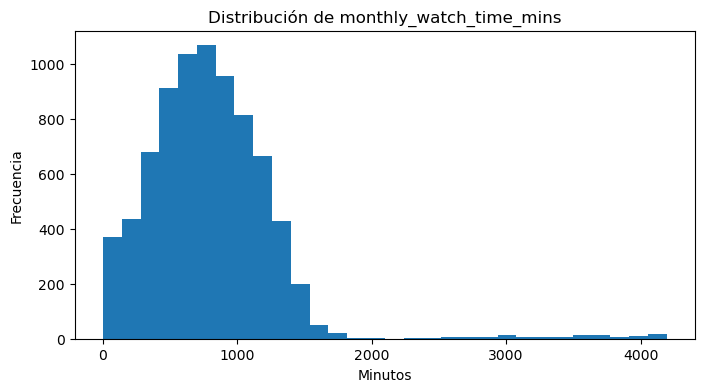

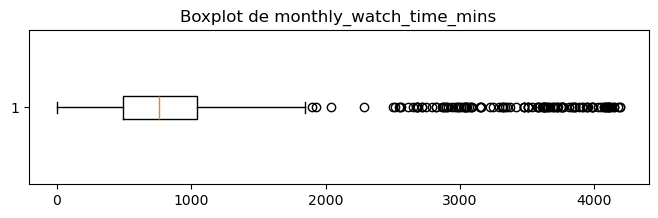

In [39]:
import matplotlib.pyplot as plt

# Histograma
plt.figure(figsize=(8, 4))
plt.hist(df_limpio["monthly_watch_time_mins"].dropna(), bins=30)
plt.title("Distribución de monthly_watch_time_mins")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot
plt.figure(figsize=(8, 2))
plt.boxplot(df_limpio["monthly_watch_time_mins"].dropna(), vert=False)
plt.title("Boxplot de monthly_watch_time_mins")
plt.show()

## Paso 17. Identificación de valores atípicos e inconsistentes

El análisis descriptivo mostró la presencia de valores extremadamente altos y también valores negativos en la variable `monthly_watch_time_mins`. Dado que un tiempo de visualización no puede ser negativo y que algunos valores parecen poco realistas, se procede a identificarlos antes de realizar la imputación de los datos faltantes.

Este paso permite verificar la magnitud del problema y fundamentar las decisiones de limpieza posteriores.

In [41]:
# Valores negativos
df_limpio[df["monthly_watch_time_mins"] < 0]

/var/folders/_p/2fd191g54y57k3dfyjkknk1m0000gn/T/ipykernel_3956/2988092306.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_limpio[df["monthly_watch_time_mins"] < 0]


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
443,10443,31.0,estandar,NaN,chile,thriller,2019-06-07,1.0
797,10797,31.0,basico,NaN,mexico,comedia,2023-07-01,1.0
1126,11126,NaN,premium,NaN,colombia,documental,2021-01-24,1.0
1186,11186,35.0,premium,NaN,brasil,drama,2022-12-09,0.0
1340,11340,40.0,estandar,NaN,peru,documental,2023-05-28,2.0
1466,11466,13.0,estandar,NaN,peru,accion,2018-03-02,1.0
1725,11725,28.0,estandar,NaN,peru,comedia,2022-06-29,0.0
1843,11843,38.0,basico,NaN,argentina,accion,2025-08-10,1.0
2318,12318,29.0,estandar,NaN,chile,documental,2018-05-05,1.0
2384,12384,33.0,estandar,NaN,uruguay,NaN,2020-09-13,1.0


In [42]:
# Valores extremadamente altos (mayores a 10000 minutos)
df_limpio[df["monthly_watch_time_mins"] > 10000]

/var/folders/_p/2fd191g54y57k3dfyjkknk1m0000gn/T/ipykernel_3956/1635458916.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_limpio[df["monthly_watch_time_mins"] > 10000]


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
176,10176,30.0,basico,NaN,brasil,NaN,2019-10-24,1.0
430,10430,16.0,basico,NaN,argentina,drama,NaT,3.0
481,10481,37.0,estandar,NaN,chile,thriller,2020-07-21,0.0
588,10588,31.0,basico,NaN,brasil,documental,2020-03-26,1.0
1072,11072,22.0,estandar,NaN,brasil,drama,2018-05-31,2.0
1250,11250,49.0,basico,NaN,brasil,drama,2024-12-13,1.0
1304,11304,13.0,basico,NaN,peru,crimen,2024-10-22,0.0
1598,11598,37.0,estandar,NaN,uruguay,crimen,2025-07-27,1.0
2313,12313,66.0,basico,NaN,argentina,accion,NaT,2.0
2450,12450,29.0,basico,NaN,colombia,accion,2021-09-05,1.0


## Paso 18. Verificación de Limpieza Aplicada

Luego de reemplazar los valores inconsistentes por NaN, se realiza una verificación para comprobar que ya no existan registros con tiempos de visualización negativos o superiores al límite establecido durante el proceso de limpieza.

Esta validación permite confirmar que las transformaciones fueron aplicadas correctamente antes de proceder con la imputación de los valores faltantes.

In [55]:
# Cantidad de valores negativos
negativos = (df_limpio["monthly_watch_time_mins"] < 0).sum()

# Cantidad de valores extremadamente altos
extremos = (df_limpio["monthly_watch_time_mins"] > 30000).sum()

print(f"Valores negativos: {negativos}")
print(f"Valores mayores a 30000 minutos: {extremos}")

Valores negativos: 0
Valores mayores a 30000 minutos: 0


## Paso 19. Imputación de `monthly_watch_time_mins`

El análisis descriptivo y gráfico realizado en los pasos anteriores mostró que la variable `monthly_watch_time_mins` presenta una distribución asimétrica con presencia de valores extremos.

Debido a estas características, se selecciona la **mediana** como estrategia de imputación, ya que constituye una medida robusta frente a outliers y representa de manera más adecuada el comportamiento central de la distribución que la media.

In [46]:
mediana_watch_time = df_limpio["monthly_watch_time_mins"].median()

df_limpio["monthly_watch_time_mins"] = (
    df_limpio["monthly_watch_time_mins"]
    .fillna(mediana_watch_time)
)

print(f"Mediana utilizada: {mediana_watch_time:.2f} minutos")

Mediana utilizada: 758.50 minutos


## Paso 20. Imputación de `age`

La variable `age` contiene valores faltantes tanto originales como generados durante el proceso de limpieza al detectar edades fuera del rango válido.

Dado que la distribución de la edad puede verse afectada por valores extremos, se utiliza la **mediana** como método de imputación.

In [49]:
mediana_edad = df_limpio["age"].median()

df_limpio["age"] = df_limpio["age"].fillna(mediana_edad)

print(f"Mediana utilizada: {mediana_edad}")

Mediana utilizada: 33.0


## Paso 21. Imputación de `favorite_genre`

Dado a que se trata de una variable categórica, usaremos la moda como método de imputación

In [48]:
moda_genero = df_limpio["favorite_genre"].mode()[0]

df_limpio["favorite_genre"] = (
    df_limpio["favorite_genre"]
    .fillna(moda_genero)
)

## Paso 22. Imputación de `age`

La variable 'last_login_date' conserva los valores 'NaT', ya que representa un dato temporal para el cual no existe un criterio objetivo que permita inferir el último acceso de un usuario.
Imputar fechas artificiales podría introducir sesgos en análisis posteriores, por lo que se opta por mantener los valores faltantes.

## Paso 23. Imputación de la variable `customer_support_tickets`

La variable `customer_support_tickets` presenta valores faltantes tanto originales como generados durante el proceso de limpieza al detectar cantidades inconsistentes de tickets.

Debido a que se trata de una variable discreta cuya distribución presenta una marcada concentración en valores bajos, se selecciona la **mediana** como estrategia de imputación, ya que resulta robusta frente a valores extremos y representa adecuadamente el comportamiento general de la variable.

In [51]:
mediana_tickets = df_limpio["customer_support_tickets"].median()

df_limpio["customer_support_tickets"] = (
    df_limpio["customer_support_tickets"]
    .fillna(mediana_tickets)
)

print(f"Mediana utilizada: {mediana_tickets}")

Mediana utilizada: 1.0


## Paso 24. Verificación de Imputaciones

In [52]:
print(df_limpio.isna().sum())

user_id                       0
age                           0
subscription_plan             0
monthly_watch_time_mins       0
country                       0
favorite_genre                0
last_login_date             784
customer_support_tickets      0
dtype: int64


## Paso 25. Verificación visual del conjunto de datos limpio

Antes de exportar el conjunto de datos procesado, se realiza una verificación visual de las principales variables modificadas durante el proceso de limpieza.

El objetivo es comprobar que las estrategias aplicadas (corrección de valores inconsistentes, normalización e imputación) produjeron resultados coherentes y que no permanecen valores claramente erróneos.

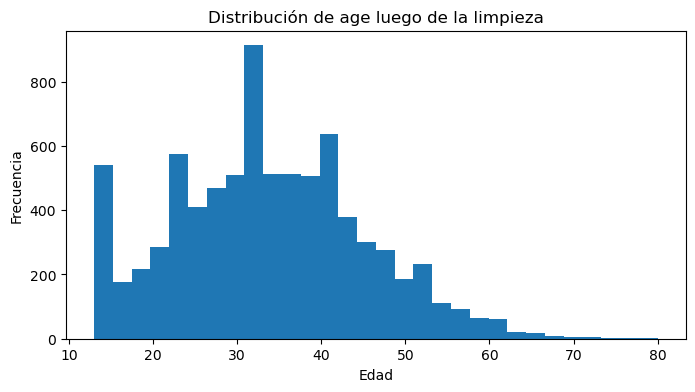

In [56]:
plt.figure(figsize=(8,4))
plt.hist(df_limpio["age"], bins=30)

plt.title("Distribución de age luego de la limpieza")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

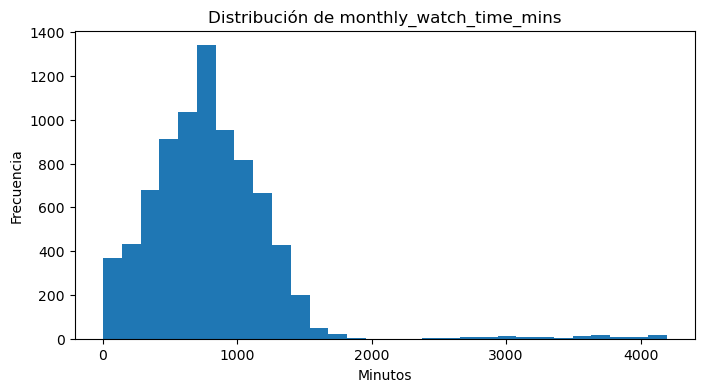

In [57]:
plt.figure(figsize=(8,4))
plt.hist(df_limpio["monthly_watch_time_mins"], bins=30)

plt.title("Distribución de monthly_watch_time_mins")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")

plt.show()

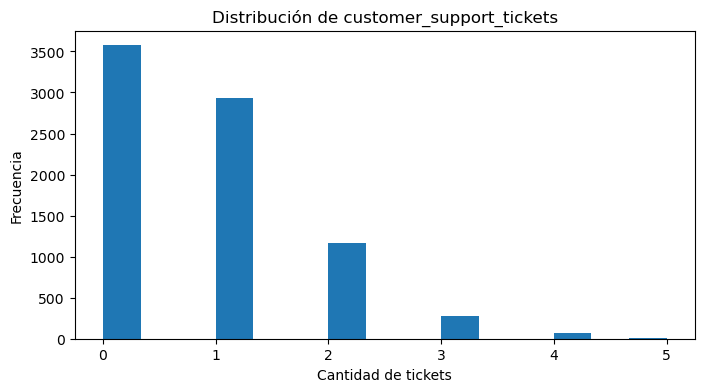

In [58]:
plt.figure(figsize=(8,4))
plt.hist(df_limpio["customer_support_tickets"], bins=15)

plt.title("Distribución de customer_support_tickets")
plt.xlabel("Cantidad de tickets")
plt.ylabel("Frecuencia")

plt.show()

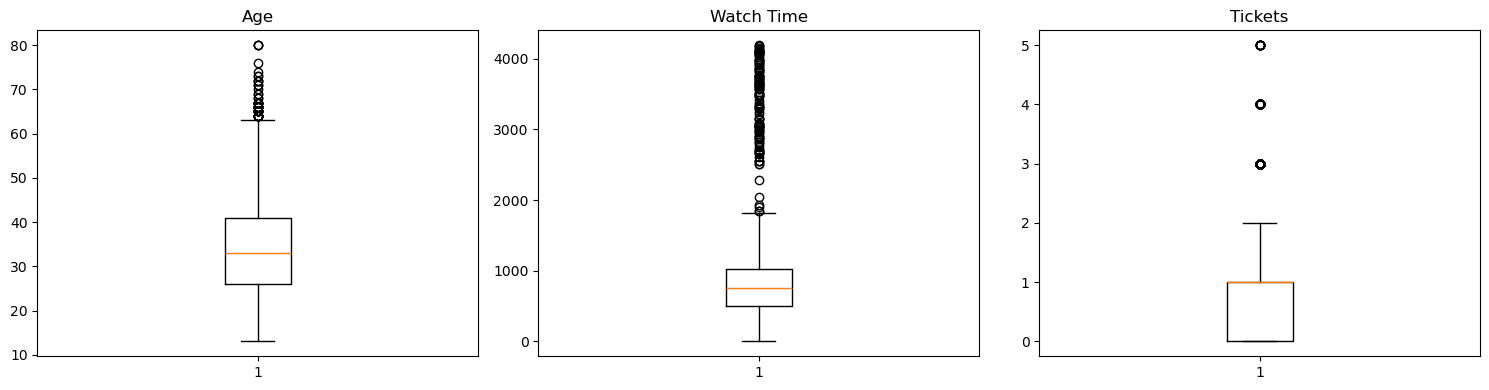

In [59]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

axes[0].boxplot(df_limpio["age"])
axes[0].set_title("Age")

axes[1].boxplot(df_limpio["monthly_watch_time_mins"])
axes[1].set_title("Watch Time")

axes[2].boxplot(df_limpio["customer_support_tickets"])
axes[2].set_title("Tickets")

plt.tight_layout()
plt.show()

In [60]:
print("Subscription Plan")
print(df_limpio["subscription_plan"].value_counts())

print("\nCountry")
print(df_limpio["country"].value_counts())

print("\nFavorite Genre")
print(df_limpio["favorite_genre"].value_counts())

Subscription Plan
subscription_plan
basico      3609
estandar    2833
premium     1592
Name: count, dtype: int64

Country
country
chile        1167
brasil       1164
mexico       1162
uruguay      1146
colombia     1145
peru         1139
argentina    1111
Name: count, dtype: int64

Favorite Genre
favorite_genre
comedia       1381
drama         1121
romance       1113
documental    1111
accion        1110
thriller      1109
crimen        1089
Name: count, dtype: int64


In [61]:
print("Dimensiones finales:", df_limpio.shape)
print("\nValores faltantes:")
print(df_limpio.isna().sum())

print("\nDuplicados:", df_limpio.duplicated().sum())

Dimensiones finales: (8034, 8)

Valores faltantes:
user_id                       0
age                           0
subscription_plan             0
monthly_watch_time_mins       0
country                       0
favorite_genre                0
last_login_date             784
customer_support_tickets      0
dtype: int64

Duplicados: 13


Al generar imputaciones en algunas variables es normal que algunos registros aparezcan duplicados.

In [62]:
df_limpio.duplicated().sum()

13

In [63]:
df_limpio = df_limpio.drop_duplicates()

In [64]:
print(df_limpio.duplicated().sum())

0


## Paso 25. Registro de las transformaciones realizadas (Pipeline Log)

Como parte del proceso ETL, resulta conveniente registrar las principales transformaciones aplicadas al conjunto de datos.

El objetivo del **Pipeline Log** es documentar cada etapa de limpieza y preparación, facilitando la trazabilidad del proceso y permitiendo reproducir las modificaciones realizadas sobre el dataset original.

In [66]:
from pathlib import Path
import pandas as pd

# Ruta del proyecto
BASE_DIR = Path.cwd().parent

# Carpeta de logs
RUTA_LOGS = BASE_DIR / "logs"

pipeline_log = pd.DataFrame({

    "Paso":[
        "Eliminación de duplicados",
        "Conversión de fechas",
        "Normalización de variables categóricas",
        "Corrección de edades",
        "Corrección de tiempos de visualización",
        "Corrección de tickets de soporte",
        "Imputación de variables numéricas",
        "Imputación de variables categóricas"
    ],

    "Descripción":[
        "Se eliminaron registros duplicados.",
        "Conversión de last_login_date a datetime.",
        "Normalización de plan, país y género.",
        "Edades fuera de rango reemplazadas por NaN e imputadas con la mediana.",
        "Valores inválidos reemplazados por NaN e imputados con la mediana.",
        "Tickets inconsistentes reemplazados por NaN e imputados con la mediana.",
        "Imputación mediante mediana en variables numéricas.",
        "Imputación mediante moda en favorite_genre."
    ]

})

pipeline_log.to_csv(
    RUTA_LOGS / "pipeline_log.csv",
    index=False
)

pipeline_log

,Paso,Descripción
0,Eliminación de duplicados,Se eliminaron registros duplicados.
1,Conversión de fechas,Conversión de last_login_date a datetime.
2,Normalización de variables categóricas,"Normalización de plan, país y género."
3,Corrección de edades,Edades fuera de rango reemplazadas por NaN e i...
4,Corrección de tiempos de visualización,Valores inválidos reemplazados por NaN e imput...
5,Corrección de tickets de soporte,Tickets inconsistentes reemplazados por NaN e ...
6,Imputación de variables numéricas,Imputación mediante mediana en variables numér...
7,Imputación de variables categóricas,Imputación mediante moda en favorite_genre.


## Paso 26. Exportación del dataset limpio

Una vez finalizado el proceso de limpieza y validación, se exporta el conjunto de datos procesado para ser utilizado en las etapas posteriores del proyecto, como el Análisis Exploratorio de Datos (EDA), el escalamiento de variables y el análisis mediante PCA.

In [67]:
# Carpeta processed
RUTA_PROCESSED = BASE_DIR / "data" / "processed"

# Exportar dataset limpio
df_limpio.to_csv(
    RUTA_PROCESSED / "dataset_limpio.csv",
    index=False
)

print("✅ dataset_limpio.csv exportado correctamente.")

✅ dataset_limpio.csv exportado correctamente.


## Paso 27. Exportación del dataset final

Finalmente se genera una copia del conjunto de datos limpio denominada `dataset_final.csv`, la cual será utilizada en las siguientes etapas del proyecto como versión definitiva del conjunto de datos preparado.

In [68]:
df_limpio.to_csv(
    RUTA_PROCESSED / "dataset_final.csv",
    index=False
)

print("✅ dataset_final.csv exportado correctamente.")

✅ dataset_final.csv exportado correctamente.


In [69]:
print("=" * 50)
print("RESUMEN DEL PROCESO DE LIMPIEZA")
print("=" * 50)

print(f"Registros finales: {df_limpio.shape[0]}")
print(f"Variables: {df_limpio.shape[1]}")

print("\nValores faltantes:")
print(df_limpio.isna().sum())

print("\nDuplicados:")
print(df_limpio.duplicated().sum())

print("\n✅ Proceso finalizado correctamente.")

RESUMEN DEL PROCESO DE LIMPIEZA
Registros finales: 8021
Variables: 8

Valores faltantes:
user_id                       0
age                           0
subscription_plan             0
monthly_watch_time_mins       0
country                       0
favorite_genre                0
last_login_date             784
customer_support_tickets      0
dtype: int64

Duplicados:
0

✅ Proceso finalizado correctamente.
